In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [6]:
transform = transforms.ToTensor()

# Load dataset
train_data = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=128, shuffle=True)

In [7]:
class AE(nn.Module):
    def __init__(self, final='sigmoid'):
        super(AE, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 32)
        )

        self.decoder = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, 784)
        )

        if final == 'sigmoid':
            self.act = nn.Sigmoid()
        else:
            self.act = nn.Tanh()

    def forward(self, x):
        x = x.view(-1, 784)
        x = self.encoder(x)
        x = self.decoder(x)
        x = self.act(x)
        return x.view(-1, 1, 28, 28)

In [8]:
def train(model):
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()
    losses = []

    for epoch in range(10):  # keep small for simplicity
        total = 0
        for x, _ in train_loader:
            out = model(x)
            loss = loss_fn(out, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total += loss.item()

        avg = total / len(train_loader)
        losses.append(avg)
        print(f"Epoch {epoch+1}, Loss: {avg:.4f}")

    return losses

In [9]:
model_sigmoid = AE(final='sigmoid')
model_tanh = AE(final='tanh')

print("Sigmoid Model")
loss_sig = train(model_sigmoid)

print("\nTanh Model")
loss_tanh = train(model_tanh)

Sigmoid Model
Epoch 1, Loss: 0.0481
Epoch 2, Loss: 0.0200
Epoch 3, Loss: 0.0149
Epoch 4, Loss: 0.0126
Epoch 5, Loss: 0.0111
Epoch 6, Loss: 0.0102
Epoch 7, Loss: 0.0095
Epoch 8, Loss: 0.0090
Epoch 9, Loss: 0.0086
Epoch 10, Loss: 0.0083

Tanh Model
Epoch 1, Loss: 0.0330
Epoch 2, Loss: 0.0201
Epoch 3, Loss: 0.0189
Epoch 4, Loss: 0.0184
Epoch 5, Loss: 0.0180
Epoch 6, Loss: 0.0176
Epoch 7, Loss: 0.0172
Epoch 8, Loss: 0.0166
Epoch 9, Loss: 0.0161
Epoch 10, Loss: 0.0157


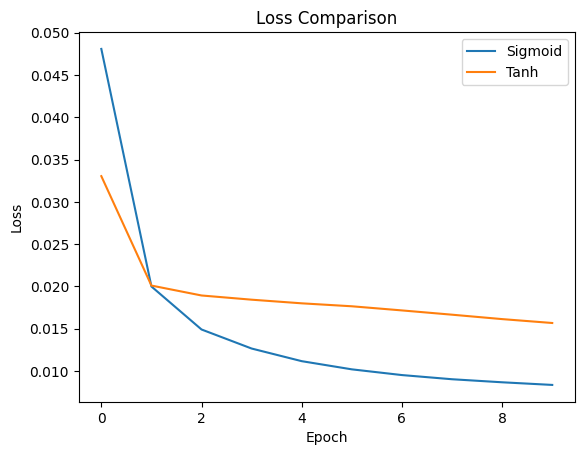

In [10]:
plt.plot(loss_sig, label='Sigmoid')
plt.plot(loss_tanh, label='Tanh')
plt.legend()
plt.title("Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Sigmoid Output


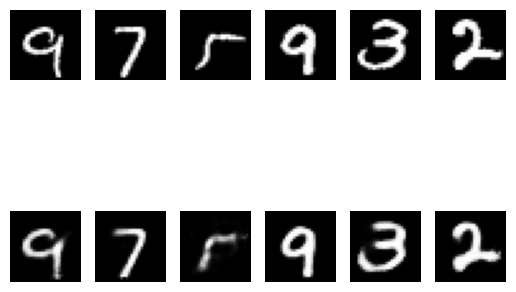

Tanh Output


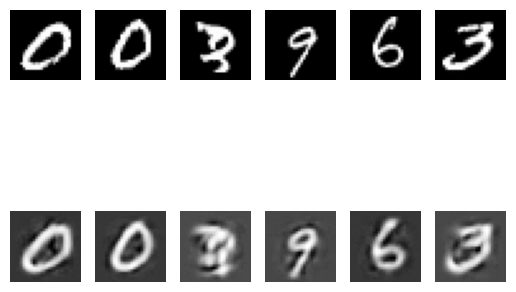

In [11]:
def show(model):
    dataiter = iter(train_loader)
    images, _ = next(dataiter)

    with torch.no_grad():
        output = model(images)

    fig, ax = plt.subplots(2, 6)

    for i in range(6):
        ax[0, i].imshow(images[i].squeeze(), cmap='gray')
        ax[0, i].axis('off')

        ax[1, i].imshow(output[i].squeeze(), cmap='gray')
        ax[1, i].axis('off')

    plt.show()

print("Sigmoid Output")
show(model_sigmoid)

print("Tanh Output")
show(model_tanh)